# 00. Análisis de Correlación Térmica y Ambiental (Spearman)

Este notebook está enfocado exclusivamente en el análisis exploratorio de correlaciones para la Isla de Calor Urbana Superficial (SUHI) en Monterrey (2026):
1. **Gráfico de Dispersión (Scatterplot):** Relación empírica entre la temperatura de superficie (LST) y la cobertura verde.
2. **Matrices de Correlación de Spearman:** A escala micro (malla de 30m) y escala socioambiental (AGEB censal).

In [1]:
import os
import sys
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Asegurar que estamos en el directorio raíz para las importaciones de src
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

from src.stats import plot_correlation_matrix

# Cargar la malla maestra v3
malla_path = "data/processed/malla_maestra_mty_2026_v3.gpkg"
if not os.path.exists(malla_path):
    malla_path = os.path.join("..", malla_path)

print(f"Cargando malla maestra desde: {malla_path}...")
gdf = gpd.read_file(malla_path)
print(f"Malla maestra v3 cargada con {len(gdf)} celdas.")

Cargando malla maestra desde: data/processed/malla_maestra_mty_2026_v3.gpkg...


Malla maestra v3 cargada con 191706 celdas.


## 1. Relación Empírica: Vegetación vs. Temperatura (LST)

Graficamos el comportamiento térmico de la ciudad frente al porcentaje de cobertura vegetal de cada celda.

Gráfico de dispersión guardado en: outputs/00/correlacion_lst_vegetacion.png


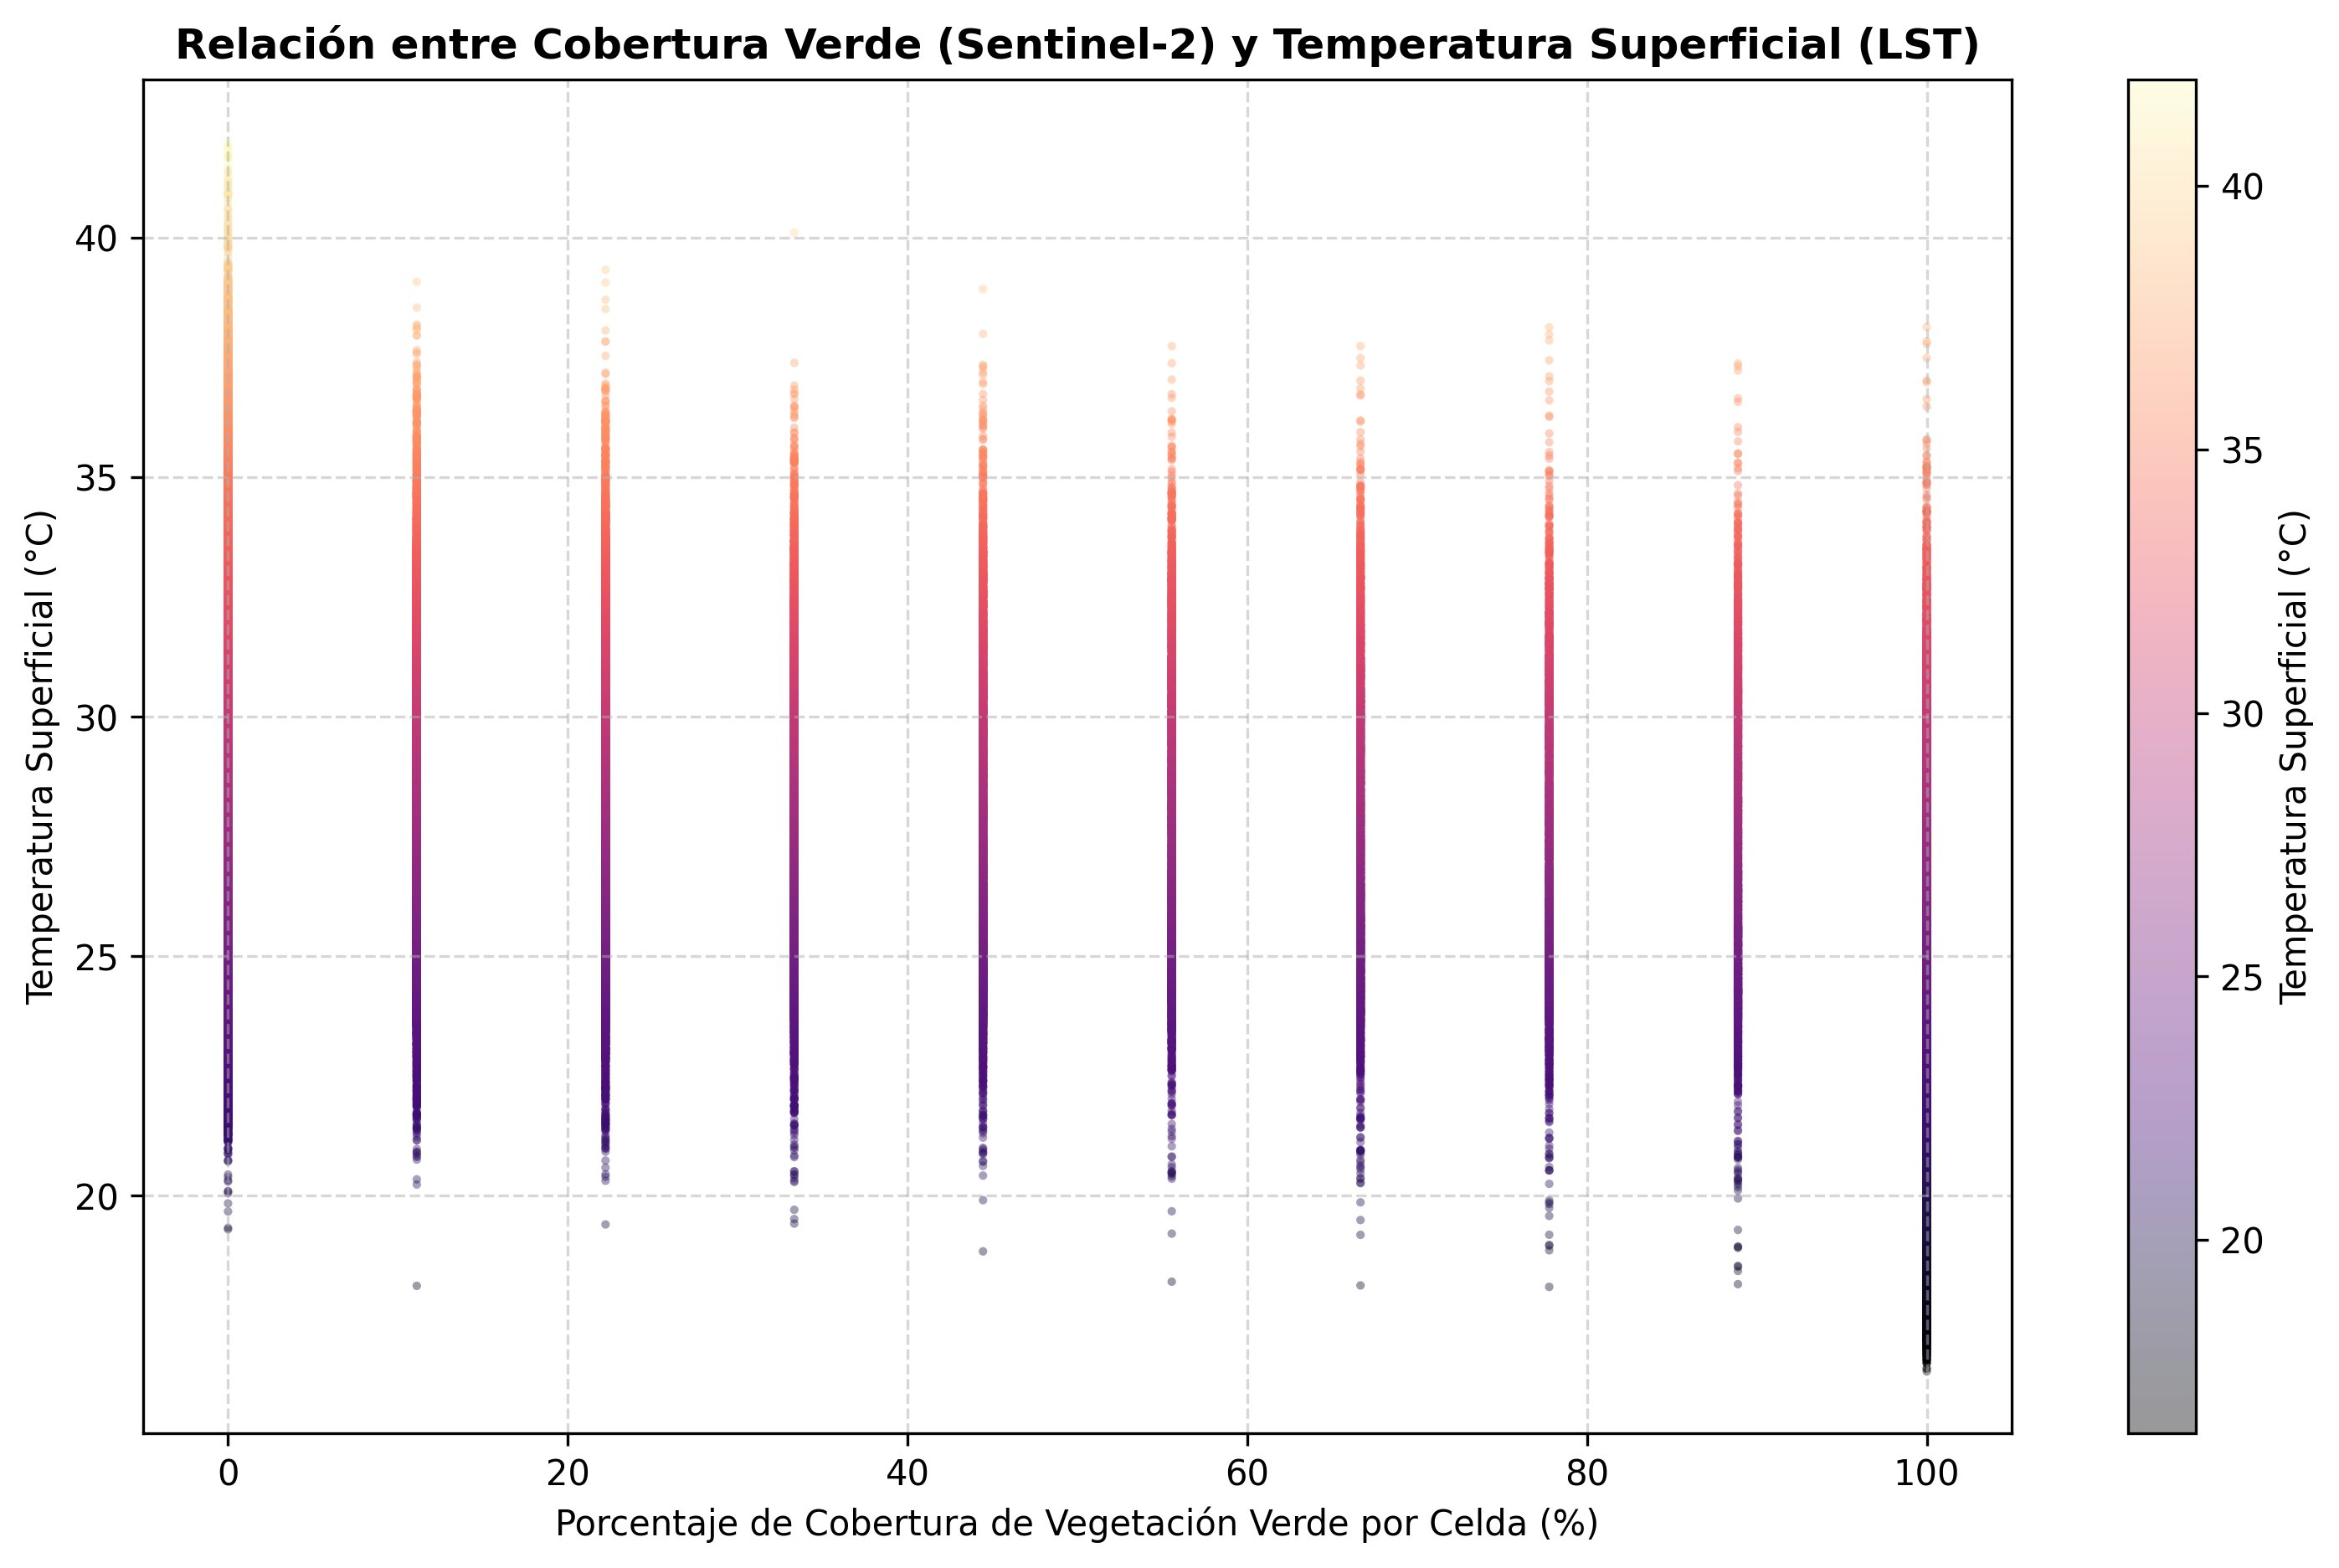

In [2]:
# Limpiar valores nulos para el gráfico
df_clean = gdf.dropna(subset=["lst_c", "green_pct"])

plt.figure(figsize=(12, 7), dpi=300)
sc = plt.scatter(
    df_clean["green_pct"],
    df_clean["lst_c"],
    alpha=0.4,
    c=df_clean["lst_c"],
    cmap="magma",
    s=6,
    edgecolors="none"
)

plt.colorbar(sc, label="Temperatura Superficial (°C)")
plt.title("Relación entre Cobertura Verde (Sentinel-2) y Temperatura Superficial (LST)", fontsize=12, fontweight='bold')
plt.xlabel("Porcentaje de Cobertura de Vegetación Verde por Celda (%)", fontsize=10)
plt.ylabel("Temperatura Superficial (°C)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

fig_sc_path = "outputs/00/correlacion_lst_vegetacion.png"
os.makedirs(os.path.dirname(fig_sc_path), exist_ok=True)
plt.savefig(fig_sc_path, dpi=300, bbox_inches='tight')
print(f"Gráfico de dispersión guardado en: {fig_sc_path}")
plt.show()

## 2. Matrices de Correlación de Spearman a Dos Escalas (30m y AGEB)

Calculamos y graficamos las correlaciones no lineales (de Spearman) para dos escalas del análisis territorial.

In [3]:
# Calcular y graficar matrices de correlación
plot_correlation_matrix(gdf)


[STATS] Generando matrices de correlación a dos escalas...


[STATS] Heatmap de correlación ambiental Spearman (30m) guardado en: C:\Users\Eydan\OneDrive\Escritorio\ITESM\MAITEC Lab\Islas de Calor\UHI_Analysis_pipeline_MVP_v1\outputs\00\04_correlacion_spearman_ambiental_30m.png
[STATS] Cargando capa maestra a escala AGEB desde: C:\Users\Eydan\OneDrive\Escritorio\ITESM\MAITEC Lab\Islas de Calor\UHI_Analysis_pipeline_MVP_v1\data\processed\ageb_maestra_mty_2026.gpkg


[STATS] Heatmap de correlación socioambiental Spearman (AGEB) guardado en: C:\Users\Eydan\OneDrive\Escritorio\ITESM\MAITEC Lab\Islas de Calor\UHI_Analysis_pipeline_MVP_v1\outputs\00\05_correlacion_spearman_socioambiental_ageb.png

   REPORTE DE AUDITORÍA: ARQUITECTURA DE DOS ESCALAS MULTITEMPORAL (SPEARMAN)
>>> Top 3 de correlaciones físicas DIURNAS a escala 30m:
  * green_pct............................... Coeficiente: -0.230 (Abs: 0.230)
  * dw_trees_pct............................ Coeficiente: -0.210 (Abs: 0.210)
  * dw_grass_pct............................ Coeficiente: -0.173 (Abs: 0.173)

>>> Top 3 de correlaciones sociales DIURNAS a escala AGEB:
  * pct_vph_snbien.......................... Coeficiente: -0.170 (Abs: 0.170)
  * pct_0_14................................ Coeficiente: -0.169 (Abs: 0.169)
  * pct_65_mas.............................. Coeficiente: +0.169 (Abs: 0.169)

>>> Confirmación de cobertura de polígonos:
  * Polígonos de AGEB integrados en el análisis final: 401

[

,lst_day_c,suhi_day_c,green_pct,industrial_osm_pct,dw_built_pct,dw_trees_pct,dw_bare_pct,dw_water_pct,dw_grass_pct,distance_to_industry_osm_m,distance_to_ternium_m,distance_to_water_m
lst_day_c,1.000000,1.000000,-0.230033,0.172683,0.157780,-0.210424,0.098061,-0.039776,-0.172769,-0.141358,-0.059851,-0.056038
suhi_day_c,1.000000,1.000000,-0.230033,0.172683,0.157780,-0.210424,0.098061,-0.039776,-0.172769,-0.141358,-0.059851,-0.056038
green_pct,-0.230033,-0.230033,1.000000,-0.123143,-0.206761,0.604245,-0.439399,0.072385,0.467104,0.267761,0.320638,-0.025766
industrial_osm_pct,0.172683,0.172683,-0.123143,1.000000,-0.136589,-0.070163,0.219547,0.207058,-0.076622,-0.513015,-0.378909,0.146269
dw_built_pct,0.157780,0.157780,-0.206761,-0.136589,1.000000,-0.442334,-0.547642,-0.538431,-0.624161,0.041667,0.033063,0.027067
dw_trees_pct,-0.210424,-0.210424,0.604245,-0.070163,-0.442334,1.000000,-0.240732,0.326157,0.581506,0.201388,0.308669,-0.073578
dw_bare_pct,0.098061,0.098061,-0.439399,0.219547,-0.547642,-0.240732,1.000000,0.303823,0.025847,-0.284801,-0.343297,0.026489
dw_water_pct,-0.039776,-0.039776,0.072385,0.207058,-0.538431,0.326157,0.303823,1.000000,0.124704,-0.180916,-0.155461,-0.040014
dw_grass_pct,-0.172769,-0.172769,0.467104,-0.076622,-0.624161,0.581506,0.025847,0.124704,1.000000,0.199825,0.300217,-0.064042
distance_to_industry_osm_m,-0.141358,-0.141358,0.267761,-0.513015,0.041667,0.201388,-0.284801,-0.180916,0.199825,1.000000,0.657630,-0.194820
